In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -----------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import joblib

In [6]:
df = pd.read_csv("diabetes_unclean.csv")

In [7]:
print(df.head())
print(df.info())

    ID  No_Pation Gender   AGE  Urea    Cr  HbA1c  Chol   TG  HDL  LDL  VLDL  \
0  502      17975      F  50.0   4.7  46.0    4.9   4.2  0.9  2.4  1.4   0.5   
1  735      34221      M  26.0   4.5  62.0    4.9   3.7  1.4  1.1  2.1   0.6   
2  420      47975      F  50.0   4.7  46.0    4.9   4.2  0.9  2.4  1.4   0.5   
3  680      87656      F  50.0   4.7  46.0    4.9   4.2  0.9  2.4  1.4   0.5   
4  504      34223      M  33.0   7.1  46.0    4.9   4.9  1.0  0.8  2.0   0.4   

    BMI CLASS  
0  24.0     N  
1  23.0     N  
2  24.0     N  
3  24.0     N  
4  21.0     N  
<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   str    
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   Hb

In [8]:
df.drop(["ID", "No_Pation"], axis=1, inplace=True)

In [9]:
print(df["Gender"].unique())

<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str


In [10]:
df["Gender"] = df["Gender"].replace({
    'f': 'F',
    'female': 'F',
    'Female': 'F',
    'm': 'M',
    'male': 'M',
    'Male': 'M'
})

In [11]:
print(df.isnull().sum())

Gender    0
AGE       1
Urea      1
Cr        2
HbA1c     3
Chol      2
TG        2
HDL       1
LDL       2
VLDL      1
BMI       0
CLASS     0
dtype: int64


In [ ]:
for column in df.columns:

    if df[column].dtype == 'object':
        # categorical
        df[column].fillna(df[column].mode()[0], inplace=True)

    else:
        # numerical
        df[column].fillna(df[column].mean(), inplace=True)

ValueError: invalid error value specified

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns = categorical_columns.drop("CLASS")

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

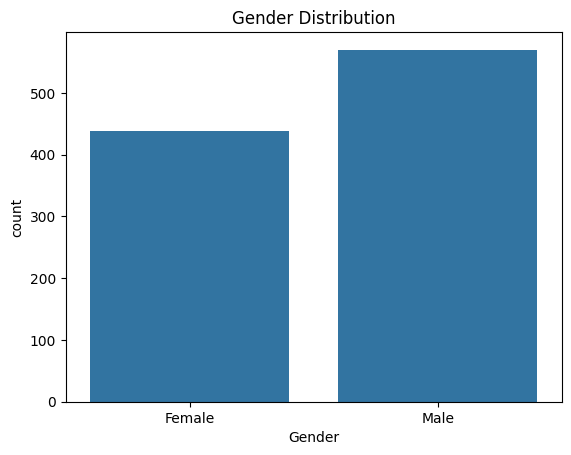

In [ ]:
sns.countplot(x='Gender_M', data=df)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.show()

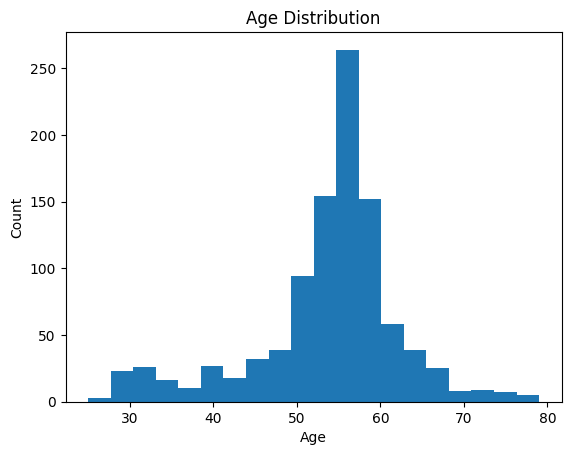

In [ ]:
plt.hist(df['AGE'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

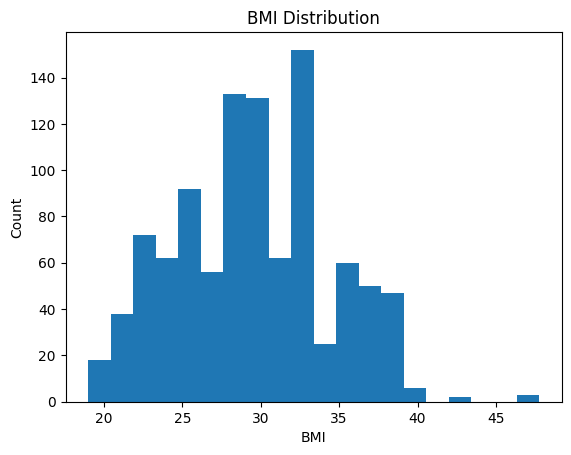

In [ ]:
plt.hist(df['BMI'], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()

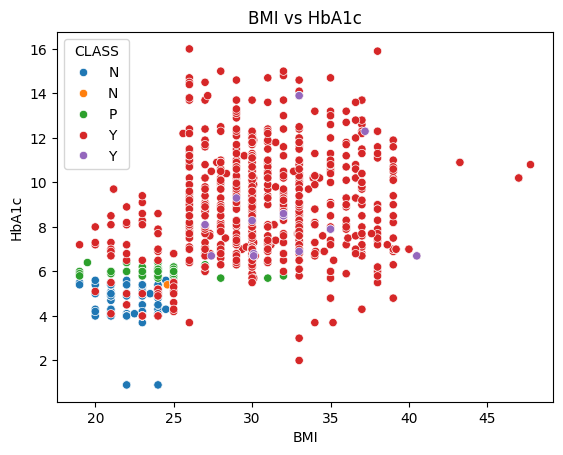

In [ ]:
sns.scatterplot(
    x='BMI',
    y='HbA1c',
    hue='CLASS',
    data=df
)

plt.title("BMI vs HbA1c")
plt.show()

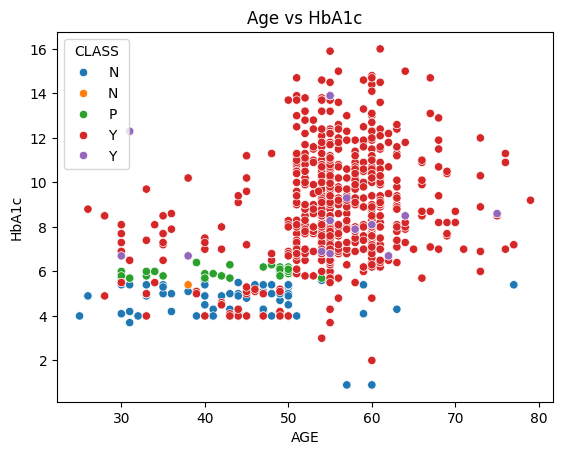

In [ ]:
sns.scatterplot(
    x='AGE',
    y='HbA1c',
    hue='CLASS',
    data=df
)

plt.title("Age vs HbA1c")
plt.show()

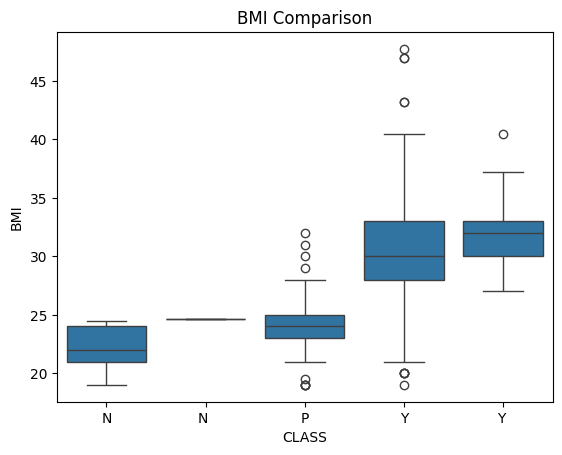

In [ ]:
sns.boxplot(
    x='CLASS',
    y='BMI',
    data=df
)

plt.title("BMI Comparison")
plt.show()

In [ ]:
X = df.drop("CLASS", axis=1)

y = df["CLASS"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000), # Increased max_iter

    "SVM": SVC(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier()
}

In [ ]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1) # Added zero_division

    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1) # Added zero_division

    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1) # Added zero_division

    # Store results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.930693   0.926781  0.930693  0.921610
1                  SVM  0.834983   0.862214  0.834983  0.759895
2        Decision Tree  0.953795   0.957001  0.953795  0.955376
3        Random Forest  0.970297   0.971008  0.970297  0.963025
4                  KNN  0.887789   0.901621  0.887789  0.887513


In [ ]:
best_model_index = results_df["F1-Score"].idxmax()

best_model_name = results_df.loc[best_model_index, "Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [ ]:
best_model = models[best_model_name]

joblib.dump(best_model, "best_diabetes_model.pkl")

['best_diabetes_model.pkl']

In [ ]:
loaded_model = joblib.load("best_diabetes_model.pkl")

In [ ]:
import joblib

# save model
joblib.dump(best_model, 'diabetes_model.pkl')

# save training columns (VERY IMPORTANT for API)
training_columns = X.columns
joblib.dump(training_columns, 'training_columns.pkl')

NameError: name 'best_model' is not defined